# TDSP — Fase de Data Exploration

Este notebook corresponde à fase de **Data Exploration** do **TDSP** (Team Data Science Process, da Microsoft), consumindo os dados brutos gerados em `code/data_acquisition/gerar_dados_brutos.py` (fase de **Data Acquisition and Understanding**).

O TDSP organiza o projeto em 5 estágios, refletidos na estrutura de pastas deste repositório:

1. **Business Understanding** — documentado em `docs/project_charter.md`.
2. **Data Acquisition and Understanding** — `code/data_acquisition/` + este notebook (exploração).
3. **Modeling** — `code/modeling/`.
4. **Deployment** — `code/deployment/`.
5. **Customer Acceptance** — `docs/exit_report.md`.

O diferencial do TDSP frente às demais metodologias deste portfólio não é o algoritmo de ML em si, mas a **disciplina de processo, papéis de equipe e documentação padronizada** (ver `docs/project_charter.md` e `docs/data_dictionary.md`), pensada para projetos conduzidos por times, não por um único analista.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

RAW_DIR = Path("../../data/raw")
INTERIM_DIR = Path("../../data/interim")
INTERIM_DIR.mkdir(parents=True, exist_ok=True)


In [2]:

lojas = pd.read_csv(RAW_DIR / "lojas.csv")
vendas = pd.read_csv(RAW_DIR / "vendas_mensais.csv")

print("Lojas:", lojas.shape)
print("Vendas mensais:", vendas.shape)
lojas.head()


Lojas: (60, 5)
Vendas mensais: (1720, 4)


,loja_id,regiao,tipo_loja,area_m2,meses_operacao
0,1,Sudeste,Shopping,186.8,26
1,2,Norte,Shopping,220.5,54
2,3,Nordeste,Rua,214.7,13
3,4,Sul,Shopping,118.3,51
4,5,Sudeste,Shopping,276.7,10


In [3]:

vendas.head()


,loja_id,ano_mes,receita,teve_campanha
0,1,2023-01,12515.07,0
1,1,2023-02,14003.56,0
2,1,2023-03,11931.15,0
3,1,2023-04,13060.76,1
4,1,2023-05,10962.63,1


## Qualidade dos dados

Antes de explorar padrões, verificamos valores ausentes, duplicidades e a cobertura de histórico por loja — conforme o checklist padrão do TDSP para esta fase.


In [4]:

print("Valores ausentes - lojas:")
print(lojas.isna().sum())
print()
print("Valores ausentes - vendas:")
print(vendas.isna().sum())
print()
print("Duplicidades em vendas (loja_id, ano_mes):", vendas.duplicated(subset=["loja_id", "ano_mes"]).sum())


Valores ausentes - lojas:
loja_id           0
regiao            0
tipo_loja         0
area_m2           0
meses_operacao    0
dtype: int64

Valores ausentes - vendas:
loja_id          0
ano_mes          0
receita          0
teve_campanha    0
dtype: int64

Duplicidades em vendas (loja_id, ano_mes): 0


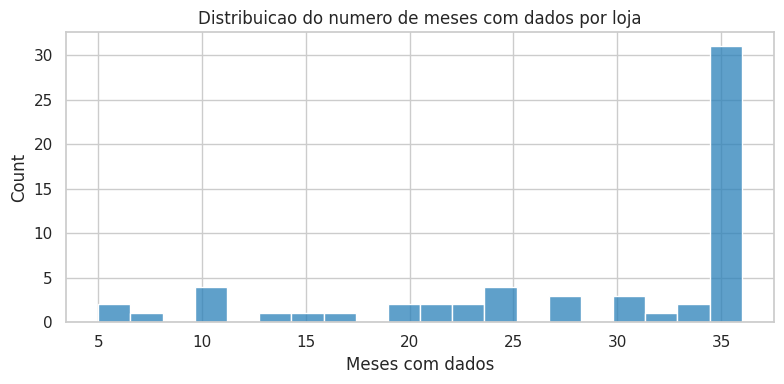

Lojas com menos de 6 meses de historico (excluir da modelagem): 1


In [5]:

historico_por_loja = vendas.groupby("loja_id").size().rename("meses_com_dados")
plt.figure(figsize=(8, 4))
sns.histplot(historico_por_loja, bins=20, color="#2980b9")
plt.title("Distribuicao do numero de meses com dados por loja")
plt.xlabel("Meses com dados")
plt.tight_layout()
plt.show()

lojas_pouco_historico = historico_por_loja[historico_por_loja < 6]
print(f"Lojas com menos de 6 meses de historico (excluir da modelagem): {len(lojas_pouco_historico)}")


## Junção e exploração da variável-alvo

Vamos unir os dois datasets e explorar a distribuição de receita por região e tipo de loja.


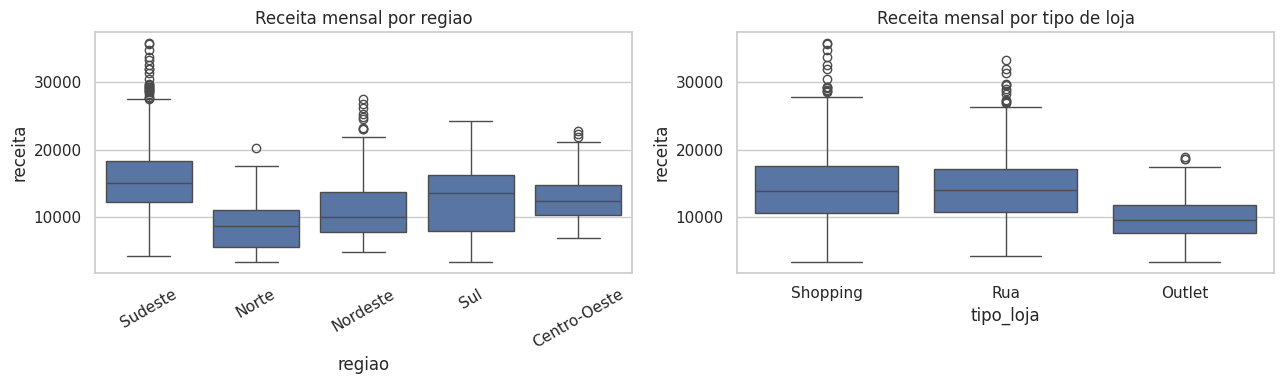

In [6]:

df = vendas.merge(lojas, on="loja_id", how="left")
df["ano_mes"] = pd.to_datetime(df["ano_mes"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="regiao", y="receita", ax=axes[0])
axes[0].set_title("Receita mensal por regiao")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="tipo_loja", y="receita", ax=axes[1])
axes[1].set_title("Receita mensal por tipo de loja")
plt.tight_layout()
plt.show()


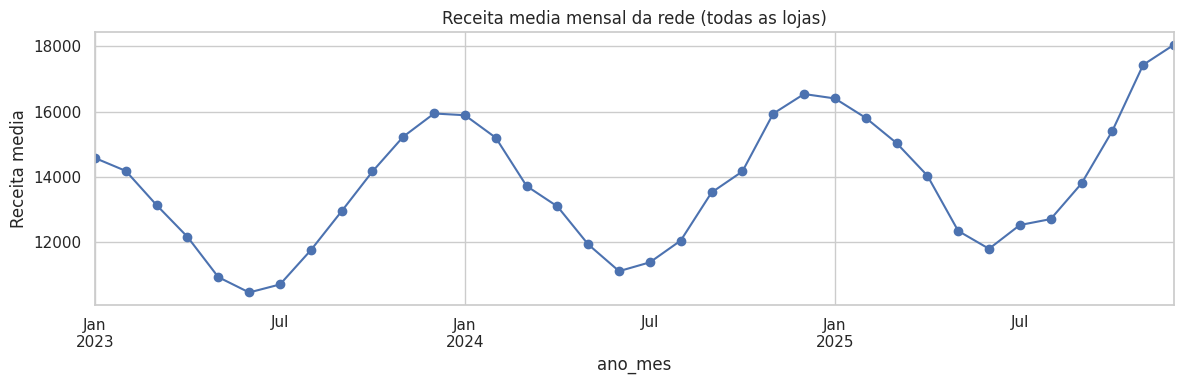

In [7]:

receita_media_mensal = df.groupby("ano_mes")["receita"].mean()
plt.figure(figsize=(12, 4))
receita_media_mensal.plot(marker="o")
plt.title("Receita media mensal da rede (todas as lojas)")
plt.ylabel("Receita media")
plt.tight_layout()
plt.show()


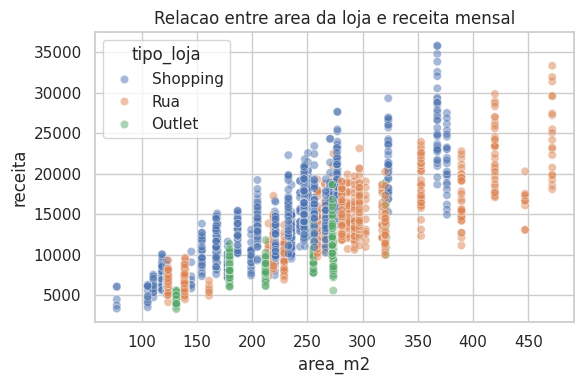

Correlacao area x receita: 0.76


In [8]:

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="area_m2", y="receita", hue="tipo_loja", alpha=0.5)
plt.title("Relacao entre area da loja e receita mensal")
plt.tight_layout()
plt.show()

print("Correlacao area x receita:", df["area_m2"].corr(df["receita"]).round(3))


## Achados da exploração

- Lojas em **Shopping** e na região **Sudeste** têm receita mediana mais alta — consistente com os pesos usados na geração dos dados, e um padrão plausível para o cenário de negócio.
- Há sazonalidade clara na receita média da rede ao longo do ano.
- Área da loja tem correlação positiva forte com a receita, como esperado.
- Um pequeno grupo de lojas tem menos de 6 meses de histórico e será removido do conjunto de modelagem, por não ter dados suficientes para gerar variáveis de lag confiáveis.

## Saída desta fase

Salvamos o dataset limpo e unido (sem as lojas de histórico insuficiente) em `data/interim/`, pronto para a fase de engenharia de variáveis no notebook de modelagem.


In [9]:

lojas_validas = historico_por_loja[historico_por_loja >= 6].index
df_limpo = df[df["loja_id"].isin(lojas_validas)].sort_values(["loja_id", "ano_mes"]).reset_index(drop=True)

df_limpo.to_parquet(INTERIM_DIR / "vendas_limpo.parquet", index=False)
print("Salvo em data/interim/vendas_limpo.parquet:", df_limpo.shape)


Salvo em data/interim/vendas_limpo.parquet: (1715, 8)
